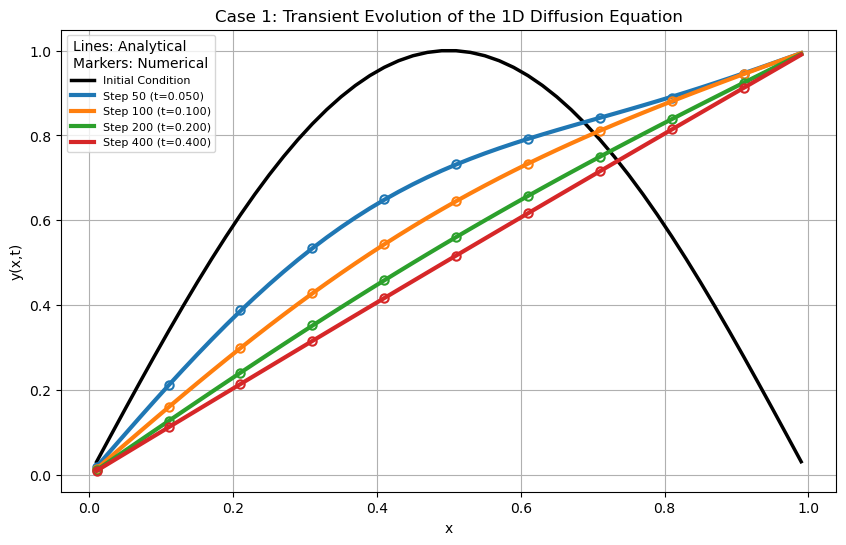

In [8]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# TRANSIENT STUDY
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 2000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_initial = np.array(y.value)

# =====================================================
# DIRICHLET BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=k)

# =====================================================
# ANALYTICAL TRANSIENT SOLUTION
# =====================================================

def analytical_solution(x, t, terms=100):

    y_ana = x.copy()

    xx = np.linspace(0, 1, 5000)

    for n in range(1, terms + 1):

        integrand = (
            np.sin(np.pi * xx) - xx
        ) * np.sin(n * np.pi * xx)

        Bn = 2 * np.trapz(integrand, xx)

        y_ana += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(-(n**2) * (np.pi**2) * t)
        )

    return y_ana

# =====================================================
# TRANSIENT EVOLUTION
# =====================================================

plt.figure(figsize=(10, 6))

# Initial Condition

plt.plot(
    x,
    y_initial,
    'k',
    linewidth=2.5,
    label='Initial Condition'
)

plot_steps = [50, 100, 200, 400]

colors = ['C0', 'C1', 'C2', 'C3']

counter = 0

for step in range(1, steps + 1):

    eq.solve(var=y, dt=dt)

    if step in plot_steps:

        t_current = step * dt

        y_num = np.array(y.value)

        y_ana = analytical_solution(
            x,
            t_current,
            terms=100
        )

        color = colors[counter]

        # ==========================================
        # ANALYTICAL SOLUTION (CONTINUOUS LINE)
        # ==========================================

        plt.plot(
            x,
            y_ana,
            color=color,
            linewidth=3,
            label=f'Step {step} (t={t_current:.3f})'
        )

        # ==========================================
        # NUMERICAL SOLUTION (HOLLOW CIRCLES)
        # ==========================================

        plt.plot(
            x[::5],
            y_num[::5],
            'o',
            color=color,
            markersize=6,
            fillstyle='none',
            markeredgewidth=1.5
        )

        counter += 1

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Transient Evolution of the 1D Diffusion Equation"
)

plt.xlabel("x")
plt.ylabel("y(x,t)")

plt.grid(True)

plt.legend(
    title="Lines: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Transient_Evolution_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

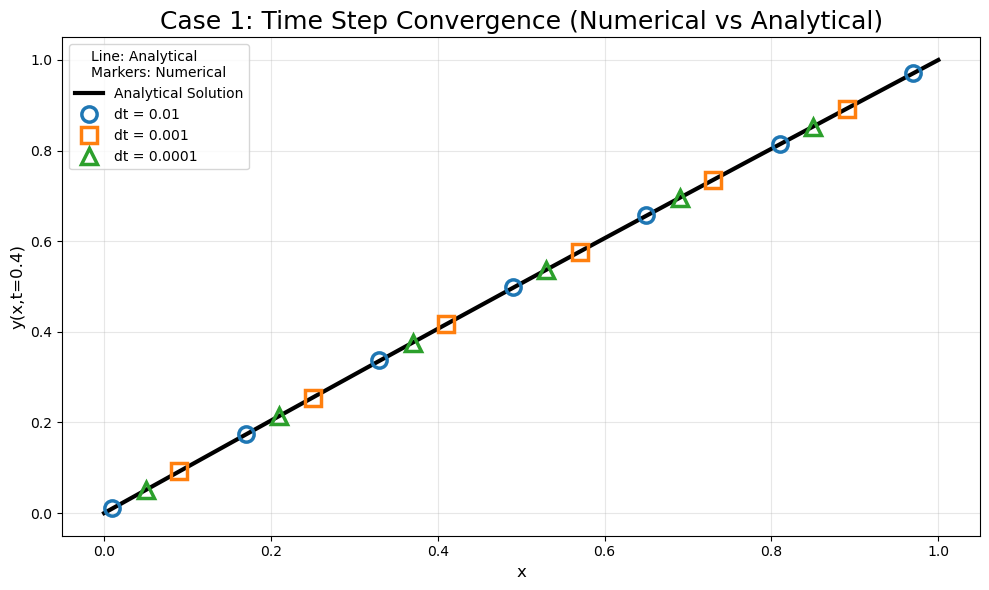

In [1]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# TIME STEP CONVERGENCE STUDY
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt_values = [1e-2, 1e-3, 1e-4]

final_time = 0.4

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

def analytical_solution(x, t, terms=100):

    y_ana = x.copy()

    xx = np.linspace(0, 1, 5000)

    for n in range(1, terms + 1):

        integrand = (
            np.sin(np.pi * xx) - xx
        ) * np.sin(n * np.pi * xx)

        Bn = 2 * np.trapz(integrand, xx)

        y_ana += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(
                -(n**2)
                * (np.pi**2)
                * t
            )
        )

    return y_ana

# =====================================================
# ANALYTICAL REFERENCE CURVE
# =====================================================

x_ref = np.linspace(0, 1, 500)

y_ana = analytical_solution(
    x_ref,
    final_time,
    terms=100
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

plt.plot(
    x_ref,
    y_ana,
    color='black',
    linewidth=3,
    label='Analytical Solution'
)

# =====================================================
# NUMERICAL SOLUTIONS
# =====================================================

markers = ['o', 's', '^']

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]

for dt, marker, color in zip(
    dt_values,
    markers,
    colors
):

    mesh = Grid1D(
        nx=nx,
        dx=dx
    )

    x = np.array(
        mesh.cellCenters[0]
    )

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions

    y.constrain(
        0.0,
        mesh.facesLeft
    )

    y.constrain(
        1.0,
        mesh.facesRight
    )

    # Governing Equation

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    steps = int(
        final_time / dt
    )

    for step in range(steps):

        eq.solve(
            var=y,
            dt=dt
        )

    numerical = np.array(
        y.value
    )

    # =================================================
    # LARGE MARKER SEPARATION
    # =================================================

    if marker == 'o':

        idx = np.array([
            0, 8, 16, 24,
            32, 40, 48
        ])

    elif marker == 's':

        idx = np.array([
            4, 12, 20, 28,
            36, 44
        ])

    else:

        idx = np.array([
            2, 10, 18, 26,
            34, 42
        ])

    plt.plot(
        x[idx],
        numerical[idx],
        linestyle='None',
        marker=marker,
        markersize=11,
        markerfacecolor='none',
        markeredgewidth=2.5,
        color=color,
        label=f'dt = {dt}'
    )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Time Step Convergence (Numerical vs Analytical)",
    fontsize=18
)

plt.xlabel(
    "x",
    fontsize=12
)

plt.ylabel(
    f"y(x,t={final_time})",
    fontsize=12
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=10,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    "Case1_TimeStep_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

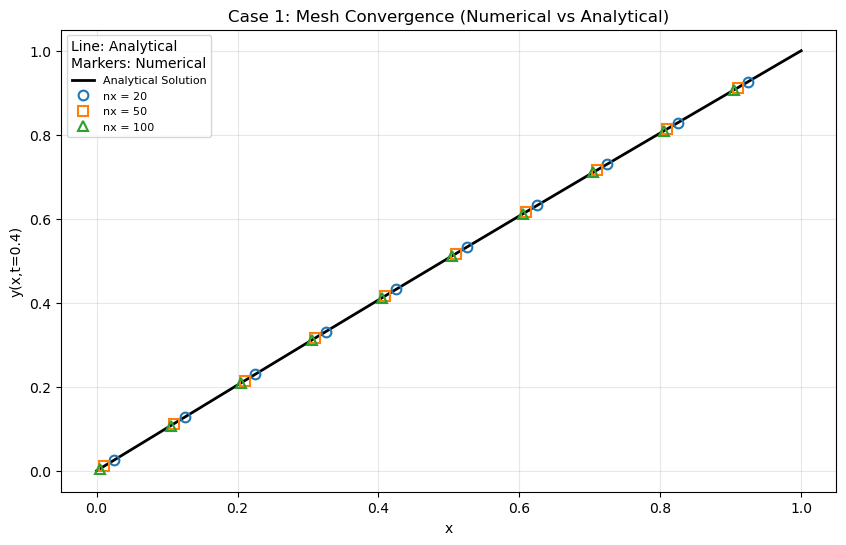

In [4]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# MESH CONVERGENCE STUDY
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
k = 1.0

dt = 1e-3
final_time = 0.4

nx_values = [20, 50, 100]

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

def analytical_solution(x, t, terms=100):

    y_ana = x.copy()

    xx = np.linspace(0, 1, 5000)

    for n in range(1, terms + 1):

        integrand = (
            np.sin(np.pi * xx) - xx
        ) * np.sin(n * np.pi * xx)

        Bn = 2 * np.trapz(integrand, xx)

        y_ana += (
            Bn
            * np.sin(n * np.pi * x)
            * np.exp(-(n**2) * (np.pi**2) * t)
        )

    return y_ana

# =====================================================
# ANALYTICAL REFERENCE CURVE
# =====================================================

x_ref = np.linspace(0, 1, 500)

y_ana = analytical_solution(
    x_ref,
    final_time,
    terms=100
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

plt.plot(
    x_ref,
    y_ana,
    color='black',
    linewidth=2.0,
    label='Analytical Solution'
)

# =====================================================
# NUMERICAL SOLUTIONS
# =====================================================

markers = ['o', 's', '^']

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]

for nx, marker, color in zip(nx_values, markers, colors):

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=k)

    steps = int(final_time / dt)

    for step in range(steps):

        eq.solve(var=y, dt=dt)

    plt.plot(
        x[::max(1, nx//10)],
        np.array(y.value)[::max(1, nx//10)],
        marker,
        color=color,
        markersize=7,
        fillstyle='none',
        markeredgewidth=1.5,
        linestyle='None',
        label=f'nx = {nx}'
    )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Mesh Convergence (Numerical vs Analytical)"
)

plt.xlabel("x")
plt.ylabel(f"y(x,t={final_time})")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Mesh_Convergence_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

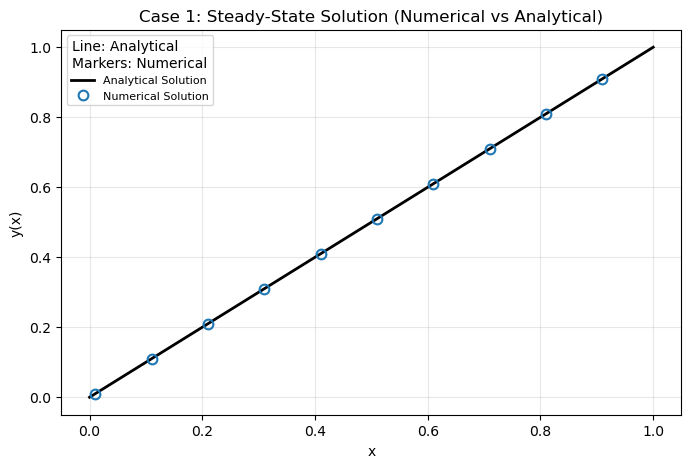

In [5]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# STEADY-STATE STUDY
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=k)

# =====================================================
# TRANSIENT TO STEADY STATE
# =====================================================

for step in range(steps):

    eq.solve(var=y, dt=dt)

# =====================================================
# ANALYTICAL STEADY-STATE SOLUTION
# =====================================================

x_ref = np.linspace(0, 1, 500)

y_analytical = x_ref

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical solution

plt.plot(
    x_ref,
    y_analytical,
    color='black',
    linewidth=2.0,
    label='Analytical Solution'
)

# Numerical solution

plt.plot(
    x[::5],
    np.array(y.value)[::5],
    'o',
    color='tab:blue',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.5,
    linestyle='None',
    label='Numerical Solution'
)

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Steady-State Solution (Numerical vs Analytical)"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Steady_State_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

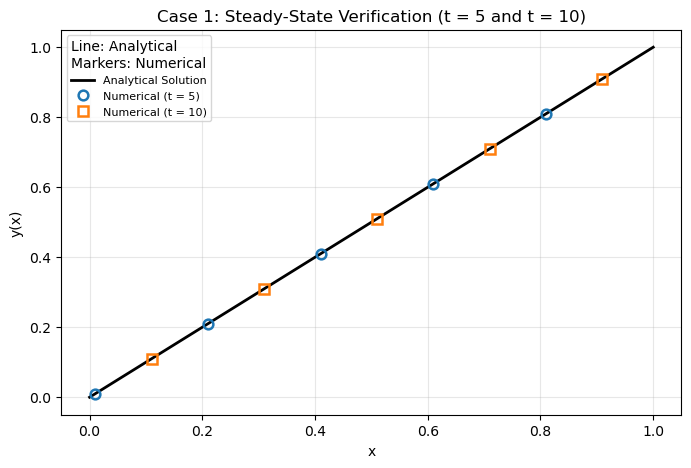

In [10]:
# =====================================================
# CASE 1 : STEADY-STATE VERIFICATION
# NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0
dt = 1e-3

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=k)

# =====================================================
# SOLUTION AT t = 5
# =====================================================

y_t5 = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_t5.constrain(0.0, mesh.facesLeft)
y_t5.constrain(1.0, mesh.facesRight)

for step in range(5000):
    eq.solve(var=y_t5, dt=dt)

solution_t5 = np.array(y_t5.value)

# =====================================================
# SOLUTION AT t = 10
# =====================================================

y_t10 = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_t10.constrain(0.0, mesh.facesLeft)
y_t10.constrain(1.0, mesh.facesRight)

for step in range(10000):
    eq.solve(var=y_t10, dt=dt)

solution_t10 = np.array(y_t10.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_ref = np.linspace(0, 1, 500)

y_analytical = x_ref

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical

plt.plot(
    x_ref,
    y_analytical,
    color='black',
    linewidth=2.0,
    label='Analytical Solution'
)

# Numerical t = 5 (circles)

plt.plot(
    x[::10],
    solution_t5[::10],
    'o',
    color='tab:blue',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical (t = 5)'
)

# Numerical t = 10 (squares shifted)

plt.plot(
    x[5::10],
    solution_t10[5::10],
    's',
    color='tab:orange',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.8,
    linestyle='None',
    label='Numerical (t = 10)'
)

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Steady-State Verification (t = 5 and t = 10)"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Steady_State_Verification_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

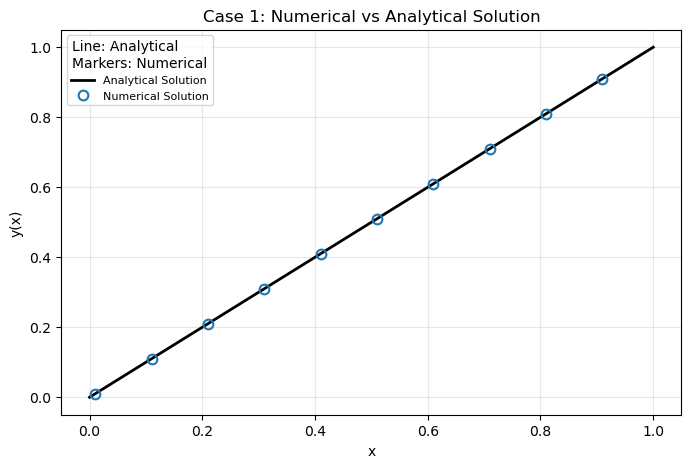

In [11]:
# =====================================================
# CASE 1 : NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=k)

for step in range(steps):
    eq.solve(var=y, dt=dt)

numerical = np.array(y.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_ref = np.linspace(0, 1, 500)

analytical = x_ref

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical Solution

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.0,
    label='Analytical Solution'
)

# Numerical Solution

plt.plot(
    x[::5],
    numerical[::5],
    'o',
    color='tab:blue',
    markersize=7,
    fillstyle='none',
    markeredgewidth=1.5,
    linestyle='None',
    label='Numerical Solution'
)

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 1: Numerical vs Analytical Solution"
)

plt.xlabel("x")
plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    fontsize=8,
    loc='best'
)

plt.savefig(
    "Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== ERROR ANALYSIS ==========
Maximum Error = 4.529710e-14
L2 Error      = 3.245800e-14


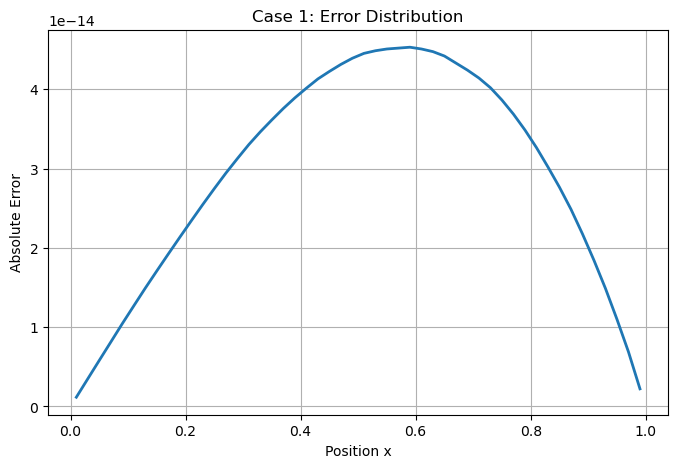

In [14]:
# =====================================================
# CASE 1 : ERROR ANALYSIS
# =====================================================

# Purpose:
#
#     Quantify the difference between the
#     numerical and analytical solutions.
#
# Metrics:
#
#     1. Maximum Error
#     2. L2 Error Norm

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

# =====================================================
# PRINT RESULTS
# =====================================================

print("\n========== ERROR ANALYSIS ==========")

print(f"Maximum Error = {max_error:.6e}")

print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 1: Error Distribution")

plt.xlabel("Position x")
plt.ylabel("Absolute Error")

plt.grid(True)
plt.savefig("error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
